In [2]:
import numpy as np
water = np.load("/gpfs001/scratch/schwar14/simudosemapheavyions/Watersimulation/Hadr01/Dataset_Miriam/1250MeV/output_nt_Hits_t0.csv")
water.shape

ValueError: Cannot load file containing pickled data when allow_pickle=False

In [1]:
import numpy as np
import pandas as pd
import glob
import os
import sys
import matplotlib.pyplot as plt
def plot(water):
    PHANTOM_SIZE = 400
    DELTA_X = 0.707031*2
    DELTA_Z = 2.5

    VOXELNUMBER_XY = int(PHANTOM_SIZE/DELTA_X)
    VOXELNUMBER_Z = int(PHANTOM_SIZE/DELTA_Z)
    dose_water_x = []
    dose_water_y = []
    dose_water_z = []
    XY_MIN = -200# -181
    XY_MAX = 200#181

    Z_MIN = -200#-229
    Z_MAX = 200#86
    DELTA_Z = 2.5
    DELTA_X = 0.707031*2
    DELTA_Y = 0.707031*2

    for x in range(VOXELNUMBER_XY):
        dose_water_x.append(np.sum(water[x, :, :]))
    for y in range(VOXELNUMBER_XY):
        dose_water_y.append(np.sum(water[:, y, :]))
    for z in range(VOXELNUMBER_Z):
        dose_water_z.append(np.sum(water[:, :, z]))

    x_vals = np.arange(XY_MIN, XY_MAX-DELTA_X, DELTA_X)
    x_vals = x_vals + DELTA_X/2

    y_vals = np.arange(XY_MIN, XY_MAX-DELTA_Y, DELTA_Y)
    y_vals = y_vals + DELTA_Y/2

    z_vals = np.arange(Z_MIN, Z_MAX, DELTA_Z)
    z_vals = z_vals + DELTA_Z/2
    # Create a 2x3 grid of subplots
    fig, axs = plt.subplots(3, figsize=(12, 8))

    axs[0].plot(x_vals, dose_water_x)
    axs[0].set_yscale('log')
    axs[0].set_xlabel('X [mm]')
    axs[0].set_ylabel('Dose [Gy]')
    axs[0].set_title('Dose Distribution in water along X direction')

    axs[1].plot(y_vals, dose_water_y)
    axs[1].set_yscale('log')
    axs[1].set_xlabel('Y [mm]')
    axs[1].set_ylabel('Dose [Gy]')
    axs[1].set_title('Dose Distribution in water along Y direction')

    axs[2].plot(z_vals, dose_water_z)
    axs[2].set_yscale('log')
    axs[2].set_xlabel('Z [mm]')
    axs[2].set_ylabel('Dose [Gy]')
    axs[2].set_title('Dose Distribution in water along Z direction')

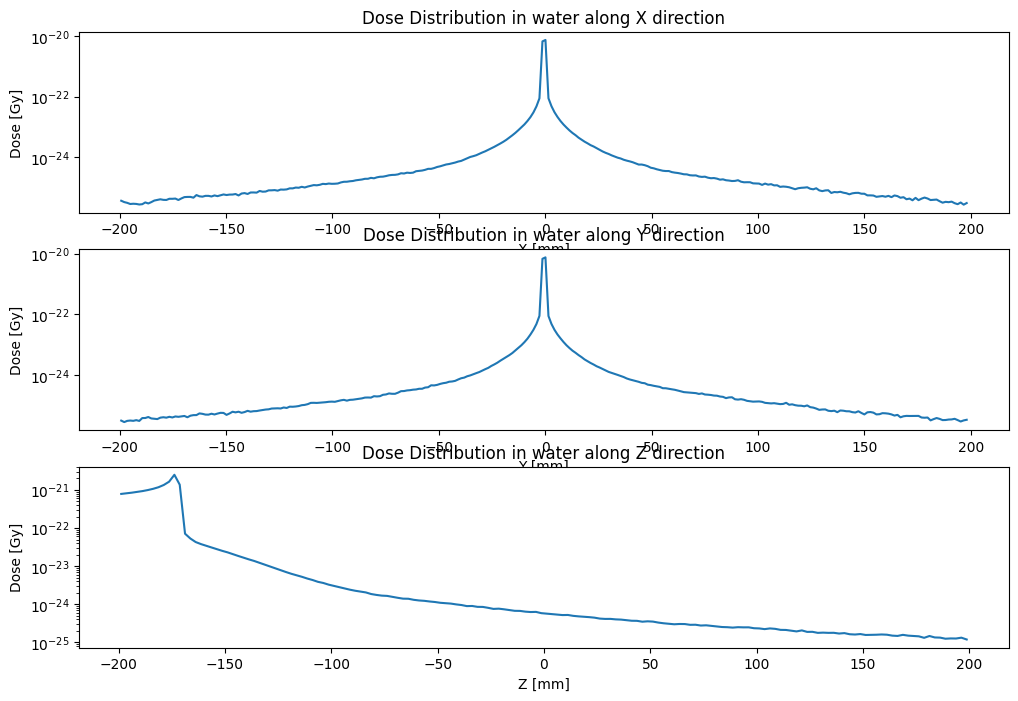

In [5]:
plot(water)

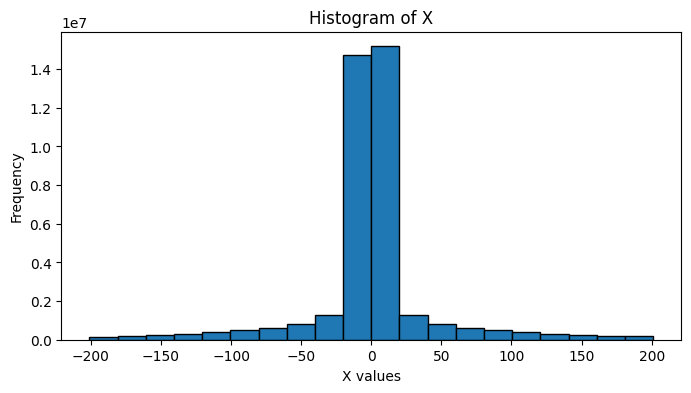

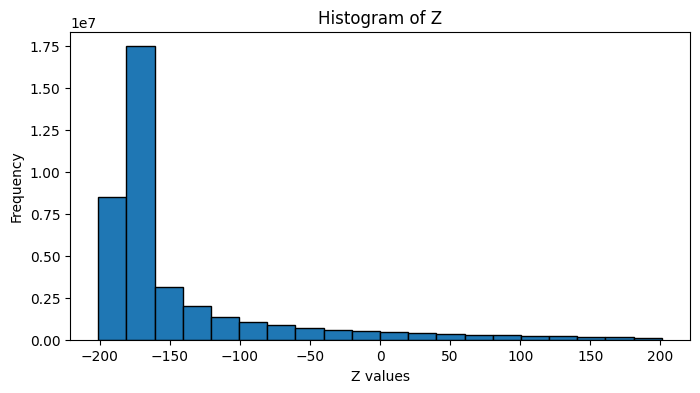

In [15]:
import matplotlib.pyplot as plt
file = '/gpfs001/scratch/schwar14/simudosemapheavyions/Watersimulation/Hadr01/build/1250MeV/output_nt_Hits_t0.csv'
sum = np.zeros(shape=(VOXELNUMBER_XY, VOXELNUMBER_XY, VOXELNUMBER_Z))

#switch X and Z value when read csv
data = pd.read_csv(file, sep = ',', skiprows = 11, names = ['X', 'Y', 'Z', 'Edep', 'Process', 'particle', 'E'])
# Plot a histogram for X
plt.figure(figsize=(8, 4))
plt.hist(data['X'], bins=20, edgecolor='black')
plt.title('Histogram of X')
plt.xlabel('X values')
plt.ylabel('Frequency')
plt.show()

# Plot a histogram for Z
plt.figure(figsize=(8, 4))
plt.hist(data['Z'], bins=20, edgecolor='black')
plt.title('Histogram of Z')
plt.xlabel('Z values')
plt.ylabel('Frequency')
plt.show()

Try with the wanted shape 256*256*126 and use my adapted code

In [4]:
import matplotlib.pyplot as plt
def plot_2(water): # target shape 256*256*126

    DELTA_X = 0.707031*2
    DELTA_Z = 2.5

    VOXELNUMBER_XY = 256
    VOXELNUMBER_Z = 126
    dose_water_x = []
    dose_water_y = []
    dose_water_z = []
    XY_MIN = -181
    XY_MAX = 181

    Z_MIN = -229
    Z_MAX = 86
    DELTA_Z = 2.5
    DELTA_X = 0.707031*2
    DELTA_Y = 0.707031*2

    for x in range(VOXELNUMBER_XY):
        dose_water_x.append(np.sum(water[x, :, :]))
    for y in range(VOXELNUMBER_XY):
        dose_water_y.append(np.sum(water[:, y, :]))
    for z in range(VOXELNUMBER_Z):
        dose_water_z.append(np.sum(water[:, :, z]))

    x_vals = np.arange(XY_MIN, XY_MAX-DELTA_X, DELTA_X)
    x_vals = x_vals + DELTA_X/2

    y_vals = np.arange(XY_MIN, XY_MAX-DELTA_Y, DELTA_Y)
    y_vals = y_vals + DELTA_Y/2

    z_vals = np.arange(Z_MIN, Z_MAX, DELTA_Z)
    z_vals = z_vals + DELTA_Z/2
    # Create a 2x3 grid of subplots
    fig, axs = plt.subplots(3, figsize=(10, 10))

    axs[0].plot(x_vals, dose_water_x)
    axs[0].set_yscale('log')
    axs[0].set_xlabel('X [mm]')
    axs[0].set_ylabel('Dose [Gy]')
    #axs[0].set_title('Dose Distribution in water along X direction')

    axs[1].plot(y_vals, dose_water_y)
    axs[1].set_yscale('log')
    axs[1].set_xlabel('Y [mm]')
    axs[1].set_ylabel('Dose [Gy]')
    #axs[1].set_title('Dose Distribution in water along Y direction')

    axs[2].plot(z_vals, dose_water_z)
    axs[2].set_yscale('log')
    axs[2].set_xlabel('Z [mm]')
    axs[2].set_ylabel('Dose [Gy]')
    #axs[2].set_title('Dose Distribution in water along Z direction')

In [21]:
import matplotlib.pyplot as plt
import numpy as np
def plot_all(dosemap,water): 
    '''plot dosemap is a 3D array containing dose data and in comparison with its dosemap in water'''

    # Shape of voxel
    VOXELNUMBER_X = 256
    VOXELNUMBER_Y = 256
    VOXELNUMBER_Z = 126

    DELTA_Z = 2.5
    DELTA_X = 0.707031*2
    DELTA_Y = 0.707031*2
    dose_x = []
    dose_y = []
    dose_z = []
    dose_water_x = []
    dose_water_y = []
    dose_water_z = []

    for x in range(VOXELNUMBER_X):
        dose_x.append(np.sum(dosemap[x, :, :]))
    for y in range(VOXELNUMBER_Y):
        dose_y.append(np.sum(dosemap[:, y, :]))
    for z in range(VOXELNUMBER_Z):
        dose_z.append(np.sum(dosemap[:, :, z]))

    for x in range(VOXELNUMBER_X):
        dose_water_x.append(np.sum(water[x, :, :]))
    for y in range(VOXELNUMBER_Y):
        dose_water_y.append(np.sum(water[:, y, :]))
    for z in range(VOXELNUMBER_Z):
        dose_water_z.append(np.sum(water[:, :, z]))
 
    x_vals = np.arange(-181, 181-DELTA_X, DELTA_X)
    x_vals = x_vals + DELTA_X/2

    y_vals = np.arange(-181, 181-DELTA_Y, DELTA_Y)
    y_vals = y_vals + DELTA_Y/2

    z_vals = np.arange(-229, 86, DELTA_Z)
    z_vals = z_vals + DELTA_Z/2

    # Create a 2x3 grid of subplots
    fig, axs = plt.subplots(2, 3, figsize=(12, 8))

    axs[0, 0].plot(x_vals, dose_x)
    axs[0, 0].set_yscale('log')
    axs[0, 0].set_xlabel('X [mm]')
    axs[0, 0].set_ylabel('Dose [Gy]')
    axs[0, 0].set_title('Dose Distribution along X direction')

    axs[0, 1].plot(y_vals, dose_y)
    axs[0, 1].set_yscale('log')
    axs[0, 1].set_xlabel('Y [mm]')
    axs[0, 1].set_ylabel('Dose [Gy]')
    axs[0, 1].set_title('Dose Distribution along Y direction')

    axs[0, 2].plot(z_vals, dose_z)
    axs[0, 2].set_yscale('log')
    axs[0, 2].set_xlabel('Z [mm]')
    axs[0, 2].set_ylabel('Dose [Gy]')
    axs[0, 2].set_title('Dose Distribution along Z direction')

    axs[1, 0].plot(x_vals, dose_water_x)
    axs[1, 0].set_yscale('log')
    axs[1, 0].set_xlabel('X [mm]')
    axs[1, 0].set_ylabel('Dose [Gy]')
    axs[1, 0].set_title('Dose Distribution in water along X direction')

    axs[1, 1].plot(y_vals, dose_water_y)
    axs[1, 1].set_yscale('log')
    axs[1, 1].set_xlabel('Y [mm]')
    axs[1, 1].set_ylabel('Dose [Gy]')
    axs[1, 1].set_title('Dose Distribution in water along Y direction')

    axs[1, 2].plot(z_vals, dose_water_z)
    axs[1, 2].set_yscale('log')
    axs[1, 2].set_xlabel('Z [mm]')
    axs[1, 2].set_ylabel('Dose [Gy]')
    axs[1, 2].set_title('Dose Distribution in water along Z direction')


    plt.tight_layout()
    plt.show()

In [22]:



water_1 = np.load("/gpfs001/scratch/schwar14/simudosemapheavyions/Watersimulation/Hadr01/build/1250MeV/dosemap25.npy")
water_1.shape
# Define the total dosemap
total_dosemap = np.zeros_like(water_1)  # Assuming water_1 has the same shape as dosemap1.npy
# Loop through dosemap files from 1 to 25
for i in range(1, 26):
    # Load each dosemap file
    filename = f"/gpfs001/scratch/schwar14/simudosemapheavyions/Watersimulation/Hadr01/build/1250MeV/dosemap{i}.npy"
    dosemap_i = np.load(filename)

    # Add the current dosemap to the total
    total_dosemap += dosemap_i


(160, 283, 283)


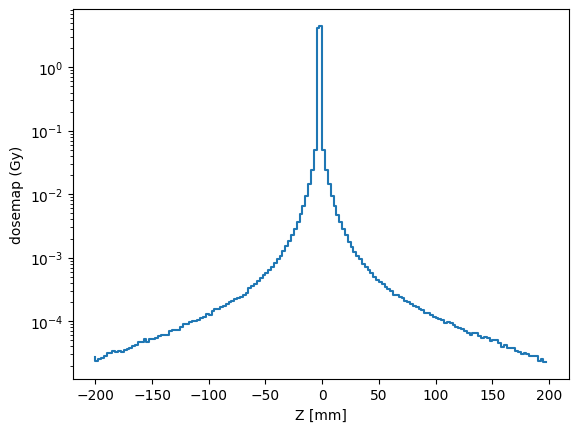

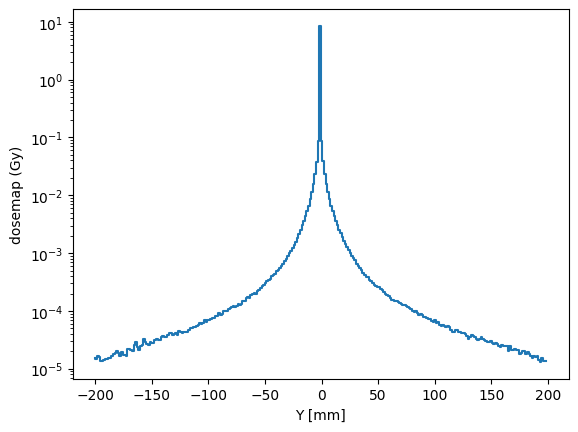

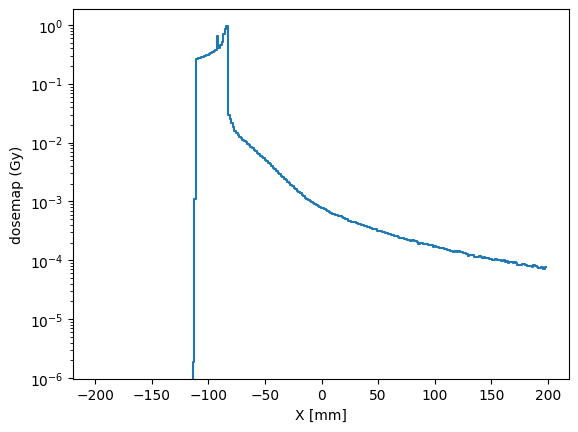

<Figure size 640x480 with 0 Axes>

In [5]:
import numpy as np
import pandas as pd
import glob
import os
import sys
import matplotlib.pyplot as plt
import getopt

file = '/gpfs001/scratch/schwar14/simudosemapheavyions/Watersimulation/Hadr01/Dataset_Miriam/1250MeV/output_nt_Hits_t0.csv'



PHANTOM_SIZE = 400
DELTA_X = 2.5
DELTA_Y = 0.707031*2
DELTA_Z = 0.707031*2

VOXELNUMBER_X = int(PHANTOM_SIZE/DELTA_X)
#+1 weil ich in der Simu aufgerundet habe und int abrundet...
VOXELNUMBER_Y = int(PHANTOM_SIZE/DELTA_Y)+1
VOXELNUMBER_Z = int(PHANTOM_SIZE/DELTA_Z)+1

SOURCE_POSITION_XY = 0
SOURCE_POSITION_Z = -200

DENSITY_WATER = 1000 #kg/m^3
WATERMASS_PER_VOXEL = DENSITY_WATER*DELTA_X*DELTA_X*DELTA_Z *(1e-9)#kg

elementarladung = 1.602176634e-19

data = pd.read_csv(file, sep = ',', skiprows = 11, names = ['X', 'Y', 'Z', 'Edep', 'Process', 'particle', 'E'])

data['Z'] = data['Z'] + 90
data_edep = data['Edep'].values

data_for_hist = data[['X', 'Y', 'Z']]

dosemap, edges = np.histogramdd(data_for_hist.values, bins = (VOXELNUMBER_X, VOXELNUMBER_Y, VOXELNUMBER_Z), range = ((-200, 200),(-200, 200),(-200, 200)), weights = data_edep)

# Umrechnen in Gray (Gy = J/kg und eV = e* J )
dosemap = dosemap*1e6*elementarladung/WATERMASS_PER_VOXEL

#dosemap_shape = (283, 283, 160)
# edges_shape: list with 3 arrays, containing the edges

print(dosemap.shape)
#Create edges for future plot
edge_1 = edges[0][:-1]
edge_2 = edges[1][:-1]
edge_3 = edges[2][:-1]

dose_z = []
for z in range(VOXELNUMBER_X):
    dose_z.append(np.sum(dosemap[z,:,:]))
plt.step(edges[0][:-1], dose_z)
plt.yscale('log')
plt.xlabel('Z [mm]')
plt.ylabel('dosemap (Gy)')
plt.show()
plt.clf()

#dosecurve Y
dose_y = []
for y in range(VOXELNUMBER_Y):
    dose_y.append(np.sum(dosemap[:,y,:]))
plt.step(edges[1][:-1], dose_y)
plt.yscale('log')
plt.xlabel('Y [mm]')
plt.ylabel('dosemap (Gy)')
plt.show()
plt.clf()

#dosecurve X
dose_x = []
for x in range(VOXELNUMBER_Z):
    dose_x.append(np.sum(dosemap[:,:,x]))
plt.step(edges[2][:-1], dose_x)
plt.yscale('log')
plt.xlabel('X [mm]')
plt.ylabel('dosemap (Gy)')
plt.show()
plt.clf()




        


In [10]:
np.save('/home/tappay01/data/zval.npy', edges[0][:-1])

np.save('/home/tappay01/data/xval.npy', edges[2][:-1])

256
max index : (79, 150, 88)
center z,y : 80 150
(256,)
max index : (80, 150, 92)
center z,y : 80 150
(256,)
max index : (79, 150, 96)
center z,y : 80 150
(256,)
max index : (79, 150, 100)
center z,y : 80 150
(256,)
max index : (79, 150, 105)
center z,y : 80 150
(256,)
max index : (79, 150, 110)
center z,y : 80 150
(256,)
max index : (79, 150, 115)
center z,y : 80 150
(256,)
max index : (80, 150, 120)
center z,y : 80 150
(256,)


max index : (79, 150, 126)
center z,y : 80 150
(256,)
max index : (79, 150, 131)
center z,y : 80 150
(256,)
max index : (79, 150, 137)
center z,y : 80 150
(256,)
max index : (79, 150, 143)
center z,y : 80 150
(256,)
max index : (79, 150, 150)
center z,y : 80 150
(256,)
max index : (80, 150, 156)
center z,y : 80 150
(256,)
max index : (79, 150, 163)
center z,y : 80 150
(256,)


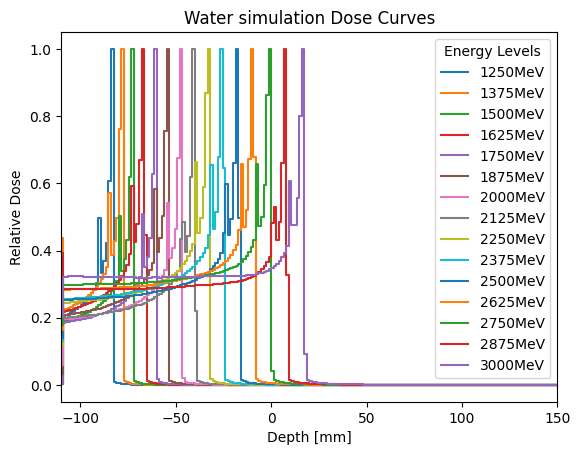

In [4]:
import numpy as np
import pandas as pd
import glob
import os
import sys
import matplotlib.pyplot as plt


def extract_centered_subsample(data, z, y, x):
    half_z = 8  # half of 16
    half_y = 8  # half of 16
    half_x = 128# half of 256
    sample = data[z-half_z:z+half_z, y-half_y:y+half_y, x-half_x:x+half_x]
    return sample


PHANTOM_SIZE = 400
DELTA_X = 2.5
DELTA_Y = 0.666016*2
DELTA_Z = 0.666016*2

VOXELNUMBER_Z = int(PHANTOM_SIZE/DELTA_Z)

voxel = np.arange(256) 

voxel_size = 0.666016*2
x_vals = (voxel*voxel_size -170.5) #- (-110) #Use depth[mm] from source as x-axis
print(len(x_vals))
min_x, max_x = min(x_vals), max(x_vals)
tick_mm_values = np.arange(-150, 150, 25)  # Adjust the start and end according to your needs
tick_mm_values = tick_mm_values[(tick_mm_values >= min_x) & (tick_mm_values <= max_x)]

file_list = ['DATASET4_1250MeV.npy',
             'DATASET4_1375MeV.npy',
             'DATASET4_1500MeV.npy',
             'DATASET4_1625MeV.npy',
             'DATASET4_1750MeV.npy',
             'DATASET4_1875MeV.npy',
             'DATASET4_2000MeV.npy',
             'DATASET4_2125MeV.npy',
             'DATASET4_2250MeV.npy',
             'DATASET4_2375MeV.npy',
             'DATASET4_2500MeV.npy',
             'DATASET4_2625MeV.npy',   
            'DATASET4_2750MeV.npy',
            'DATASET4_2875MeV.npy',
            'DATASET4_3000MeV.npy', ]
dir_path = "/home/tappay01/new_data/watersimulation/"
# Remove the prefix "DATASET4_"
legend_labels = [file.replace('DATASET4_', '').replace('.npy', '') for file in file_list]

plt.figure()

for file_name in file_list:
    file_path = os.path.join(dir_path, file_name)
    dosemap = np.load(file_path)
    max_index = np.unravel_index(dosemap.argmax(), dosemap.shape)
    print("max index :", max_index)
    print("center z,y :" ,int(dosemap.shape[0]/2), int(dosemap.shape[1]/2))

    water_sample= extract_centered_subsample(dosemap, int(max_index[0]), int(max_index[1]), int(dosemap.shape[2]/2)) 
    # Dose curve X

    water_dose_slice = water_sample[8,8, :]

    dose_x = np.array(water_dose_slice) / np.max(water_sample)
    print(dose_x.shape)
    plt.step(x_vals, dose_x, label=file_name.split('.')[0])  # Splitting to remove .npy
plt.xlim(-110,150)
plt.yscale('linear')
plt.xlabel('Depth [mm]')
plt.ylabel('Relative Dose')
plt.title('Water simulation Dose Curves')
plt.legend(legend_labels,title='Energy Levels')
plt.show()



In [ ]:
density = np.load("/scratch/tappay01/densities/Data1.npy")

# Convert the tensor to a numpy array and flatten it
density_flat = density.flatten()

# Plot the histogram
plt.hist(density_flat, bins=50, color='blue', alpha=0.7)
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.title('Histogram of density Values')
plt.grid(True)
plt.show()

total_sum  391.2186530301263


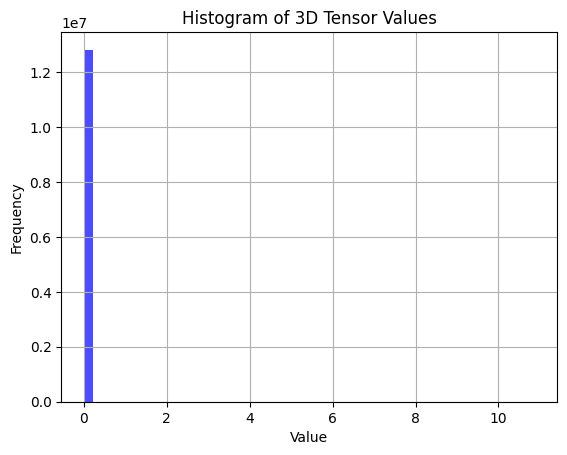

In [22]:
dosemap = np.load('/scratch/tappay01/watersimulation/DATASET/DATASET_2250MeV.npy')
total_sum = np.sum(dosemap)
print('total_sum ',total_sum)
# Convert the tensor to a numpy array and flatten it
dosemap_flat = dosemap.flatten()

# Plot the histogram
plt.hist(dosemap_flat, bins=50, color='blue', alpha=0.7)
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.title('Histogram of 3D Tensor Values')
plt.grid(True)
plt.show()

total_sum  2450.460772112644
Mean: 0.0002967544764095057
Median: 5.26431e-07
Standard Deviation: 0.025670747379490134
Min Value: 0.0
Max Value: 5.25417
25th Percentile: 7.7680675e-08
75th Percentile: 2.76132e-06


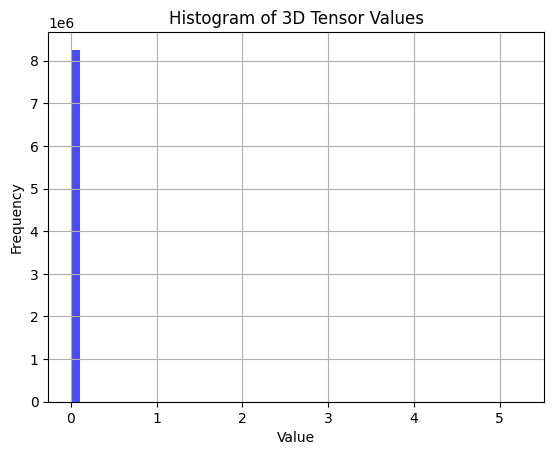

In [5]:
arr = np.load("/scratch/tappay01/data/data1/Data1_2250MeV_-25Mm_-121.5Mm.npy")
total_sum = np.sum(arr)
print('total_sum ',total_sum)
# Compute statistics
mean_value = np.mean(arr)
median_value = np.median(arr)
std_dev = np.std(arr)
min_value = np.min(arr)
max_value = np.max(arr)

percentile_25 = np.percentile(arr, 25)
percentile_75 = np.percentile(arr, 75)

# Display statistics
print(f"Mean: {mean_value}")
print(f"Median: {median_value}")
print(f"Standard Deviation: {std_dev}")
print(f"Min Value: {min_value}")
print(f"Max Value: {max_value}")
print(f"25th Percentile: {percentile_25}")
print(f"75th Percentile: {percentile_75}")
# Convert the tensor to a numpy array and flatten it
dosemap_flat = arr.flatten()

# Plot the histogram
plt.hist(dosemap_flat, bins=50, color='blue', alpha=0.7)
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.title('Histogram of 3D Tensor Values')
plt.grid(True)
plt.show()

In [6]:
xval= np.load('/home/tappay01/data/xval.npy')
zval= np.load('/home/tappay01/data/zval.npy')

(160, 301, 301)


ValueError: x and y must have same first dimension, but have shapes (283,) and (301,)

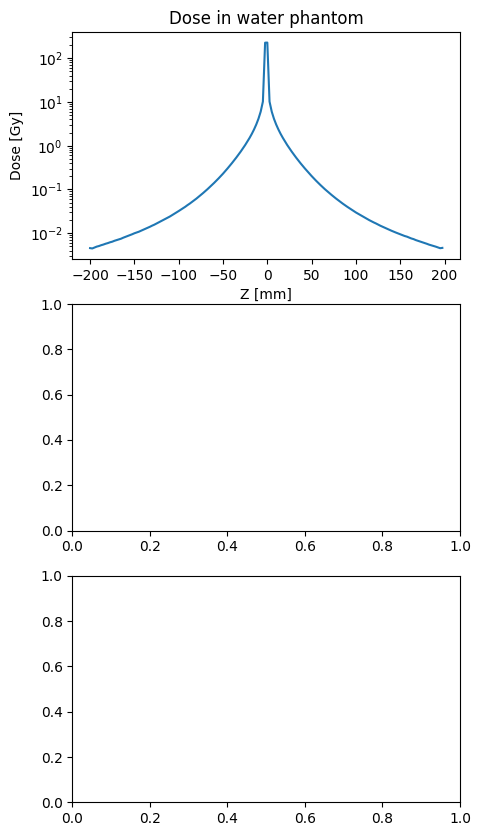

In [13]:
data = np.load("/home/tappay01/new_data/watersimulation/DATASET4_1875MeV.npy")
print(data.shape)
# Create a 2x3 grid of subplots
fig, axs = plt.subplots(3, figsize=(5, 10))
dose_z = []
dose_y = []
dose_x = []
x_vals = np.arange(-170.5, 170.5-1, 0.666016*2)
x_vals = x_vals + DELTA_X/2

for z in range(160):
    dose_z.append(np.sum(dosemap[z,:,:]))
axs[0].plot(zval, dose_z)
axs[0].set_yscale('log')
axs[0].set_xlabel('Z [mm]')
axs[0].set_ylabel('Dose [Gy]')
axs[0].set_title('Dose in water phantom')
#axs[0].set_title('Dose Distribution in water along X direction')
for y in range(301):
    dose_y.append(np.sum(dosemap[:,y,:]))
axs[1].plot(xval, dose_y)
axs[1].set_yscale('log')
axs[1].set_xlabel('Y [mm]')
axs[1].set_ylabel('Dose [Gy]')
#axs[1].set_title('Dose Distribution in water along Y direction')
for x in range(301):
    dose_x.append(np.sum(dosemap[:,:,x]))
axs[2].plot(xval, dose_x)
axs[2].set_yscale('log')
axs[2].set_xlabel('X [mm]')
axs[2].set_ylabel('Dose [Gy]')
#axs[2].set_title('Dose Distribution in water along Z direction')

In [33]:
def plot_brain(dose): #plot with shape 256*256*126
    VOXELNUMBER_X = 256
    VOXELNUMBER_Y = 256
    VOXELNUMBER_Z = 126

    DELTA_Z = 2.5
    DELTA_X = 0.707031*2
    DELTA_Y = 0.707031*2

    x_vals = np.arange(-181, 181-DELTA_X, DELTA_X)
    x_vals = x_vals + DELTA_X/2

    y_vals = np.arange(-181, 181-DELTA_Y, DELTA_Y)
    y_vals = y_vals + DELTA_Y/2

    z_vals = np.arange(-229, 86-DELTA_Z, DELTA_Z) 
    z_vals = z_vals + DELTA_Z/2


    dose_x = []
    dose_y = []
    dose_z = []
    for x in range(VOXELNUMBER_X):
        dose_x.append(np.sum(dose[x, :,:]))
    for y in range(VOXELNUMBER_Y):
        dose_y.append(np.sum(dose[:,y,:]))
    for z in range(VOXELNUMBER_Z):
        dose_z.append(np.sum(dose[:,:,z]))
    del dose_z[0]
    # Create a 2x3 grid of subplots
    fig, axs = plt.subplots(3, figsize=(5, 10))

    axs[0].plot(x_vals, dose_x)
    axs[0].set_yscale('log')
    axs[0].set_xlabel('X [mm]')
    axs[0].set_ylabel('Dose [Gy]')
    axs[0].set_title('Dose in head phantom')
    #axs[0].set_title('Dose Distribution in water along X direction')

    axs[1].plot(y_vals, dose_y)
    axs[1].set_yscale('log')
    axs[1].set_xlabel('Y [mm]')
    axs[1].set_ylabel('Dose [Gy]')
    #axs[1].set_title('Dose Distribution in water along Y direction')

    axs[2].plot(z_vals, dose_z)
    axs[2].set_yscale('log')
    axs[2].set_xlabel('Z [mm]')
    axs[2].set_ylabel('Dose [Gy]')
    #axs[2].set_title('Dose Distribution in water along Z direction')

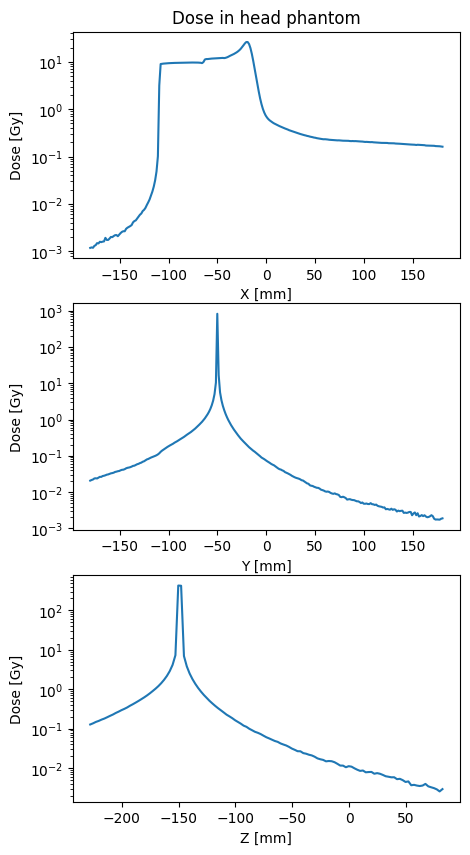

In [34]:
plot_brain(resized)